# 2D Fractional PDE — Figures for the Paper

This notebook **loads pre-trained model weights** and regenerates the figures
used in the manuscript. It does not perform training — see `2DfPDE_solver.ipynb`
for that.

## Contents

1. **Configuration** — domain, grid, and plotting settings.
2. **Imports & setup** — libraries and matplotlib style.
3. **Model architecture** — same network class as the solver (needed to load weights).
4. **Exact solution** — analytical reference for comparison.
5. **Collocation-point study** — comparison across `NX = NT ∈ {10, 20, 50}`.
6. **Time-window study** — comparison between `TMAX = 0.5` and `TMAX = 1.0`.
7. **Diethelm vs L1 comparison** — line plots comparing the two schemes at several time snapshots.
8. **Contour comparison** — PINN vs reference on the full domain.

## 1. Configuration

In [12]:
# ---- Domain ------------------------------------------------------------
XMIN, XMAX = 0.0, 2.0     # spatial domain

# ---- Network architecture (must match the trained model) --------------
NUM_HIDDEN_LAYERS = 4
NUM_NEURONS_PER_LAYER = 20
ACTIVATION = 'tanh'
KERNEL_INITIALIZER = 'glorot_normal'

# ---- Fractional derivative --------------------------------------------
ALPHA = 0.5

# ---- Reproducibility --------------------------------------------------
RANDOM_SEED = 42

# ---- Data type --------------------------------------------------------
DTYPE = 'float32'

# ---- Plot style -------------------------------------------------------
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
          'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
          'gold', 'lightcoral', 'k']
MARKERS = ['o', 'v', 'x', 's', '+', '^', '1', '2', 'd', '<', '>', '*', 'p']
LINE_WIDTH = [4, 3]  # solid lines, dashed lines

## 2. Imports and Setup

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator

# Set default dtype and seed
tf.keras.backend.set_floatx(DTYPE)
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Matplotlib style (LaTeX fonts)
rc('font', **{'family': 'Times'})
rc('text', usetex=True)

plt.rc('font', size=17)
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize=20)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('legend', fontsize=16)
plt.rc('figure', titlesize=20)


def gamma_tf(x):
    """Gamma function for TF tensors (via log-gamma)."""
    return tf.exp(tf.math.lgamma(x))

## 3. Model Architecture

Must match the architecture used during training — otherwise the saved weights will not load.

In [14]:
class PINN_NeuralNet(tf.keras.Model):
    """Fully-connected PINN architecture. Must match the trained model."""

    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=NUM_HIDDEN_LAYERS,
                 num_neurons_per_layer=NUM_NEURONS_PER_LAYER,
                 activation=ACTIVATION,
                 kernel_initializer=KERNEL_INITIALIZER,
                 **kwargs):
        super().__init__(**kwargs)

        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.lb = lb
        self.ub = ub

        self.hidden = [
            tf.keras.layers.Dense(
                num_neurons_per_layer,
                activation=tf.keras.activations.get(activation),
                kernel_initializer=kernel_initializer,
            )
            for _ in range(num_hidden_layers)
        ]
        self.out = tf.keras.layers.Dense(output_dim)

    def call(self, X):
        Z = X
        for layer in self.hidden:
            Z = layer(Z)
        return self.out(Z)


def load_pretrained_model(weights_path, lb, ub):
    """Instantiate a PINN and load pre-trained weights from disk."""
    model = PINN_NeuralNet(lb, ub)
    model.build(input_shape=(None, 2))
    model.load_weights(weights_path)
    return model

## 4. Exact Solution

In [15]:
def exact_solution(x, t):
    """Analytical reference solution for the benchmark problem."""
    return t ** 2 * x * (2.0 - x)

## 5. Effect of Collocation Points

Compare PINN predictions at three time snapshots (t = 0.1, 0.5, 1.0) for
different collocation densities `NX = NT ∈ {10, 20, 50}`. Pre-trained weights
are expected at `WEIGHTS_{N}t{N}x/my_model.tf`.

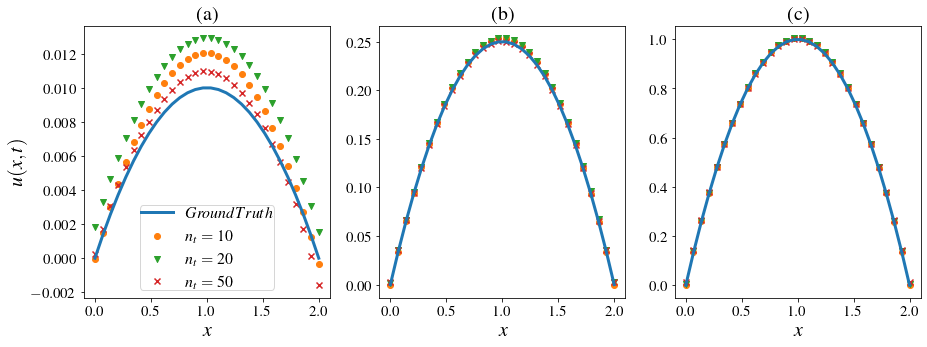

In [26]:
COL_SETS = [10, 20, 50]              # collocation grids to compare
TIME_SNAPSHOTS = [0.1, 0.5, 1.0]     # time slices to plot
N_EVAL = 30                           # number of x-points for plotting
TMAX_FOR_COL_STUDY = 1.0

lb = [XMIN, 0.0]
ub = [XMAX, TMAX_FOR_COL_STUDY]

fig, ax = plt.subplots(1, 3, sharex=False, sharey=False, figsize=(15, 5))
axs = ax.flat

xspace = np.linspace(XMIN, XMAX, N_EVAL)
sub_cap = ['(a)', '(b)', '(c)']

for i, colls in enumerate(COL_SETS):
    weights_loc = f'WEIGHTS_{colls}t{colls}x_tmax{TMAX_FOR_COL_STUDY}_cpt/my_model.tf'
    model = load_pretrained_model(weights_loc, lb, ub)

    for sub_p, t_snap in enumerate(TIME_SNAPSHOTS):
        tspace = np.full(N_EVAL, t_snap)
        X_eval = np.stack([xspace, tspace], axis=1)
        pred = model(X_eval)

        if i == 0:
            y_ref = exact_solution(xspace, tspace)
            axs[sub_p].plot(xspace, y_ref, label='$Ground Truth$',
                            lw=LINE_WIDTH[1], color=COLORS[i])

        axs[sub_p].scatter(xspace, pred, label=f'$n_t = {colls}$',
                           marker=MARKERS[i], color=COLORS[i + 1])
        axs[sub_p].title.set_text(sub_cap[sub_p])
        axs[sub_p].set_xlabel('$x$')
        axs[sub_p].set_xlim((-0.1, 2.1))
        axs[sub_p].locator_params(axis='x', nbins=5)

        if sub_p == 0:
            axs[sub_p].set_ylabel('$u(x, t)$')
            axs[sub_p].legend(borderpad=0.05)

plt.savefig('Effect_of_collocation_points.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Effect of Time Window

Compare PINN predictions trained on two different time windows
(`TMAX = 1.0` vs `TMAX = 0.5`) for the same collocation density. Expected
weights locations:
- `WEIGHTS_50t50x_tmax1.0_cpt/my_model.tf`
- `WEIGHTS_50t50x_tmax0.5_cpt/my_model.tf`

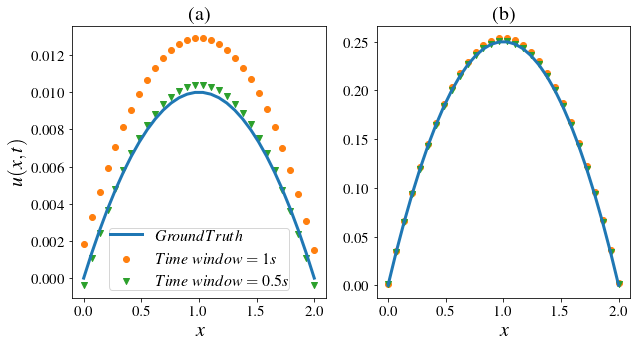

In [29]:
COLLS_TW = 20                         # collocation density for time-window study
TIME_SNAPSHOTS_TW = [0.1, 0.5]        # time slices to plot

lb_tw = [XMIN, 0.0]
ub_tw = [XMAX, 1.0]  # larger of the two time windows

fig, ax = plt.subplots(1, 2, sharex=True, sharey=False, figsize=(10, 5))
axs = ax.flat
xspace = np.linspace(XMIN, XMAX, N_EVAL)
sub_cap = ['(a)', '(b)']

# Load both pre-trained models
model_full = load_pretrained_model(
    f'WEIGHTS_{COLLS_TW}t{COLLS_TW}x_tmax1.0_cpt/my_model.tf', lb_tw, ub_tw
)
model_window = load_pretrained_model(
    f'WEIGHTS_{COLLS_TW}t{COLLS_TW}x_tmax0.5_cpt/my_model.tf', lb_tw, ub_tw
)

for sub_p, t_snap in enumerate(TIME_SNAPSHOTS_TW):
    tspace = np.full(N_EVAL, t_snap)
    X_eval = np.stack([xspace, tspace], axis=1)

    pred_full = model_full(X_eval)
    pred_window = model_window(X_eval)
    y_ref = exact_solution(xspace, tspace)

    axs[sub_p].plot(xspace, y_ref, label='$Ground Truth$',
                    lw=LINE_WIDTH[1], color=COLORS[0])
    axs[sub_p].scatter(xspace, pred_full, label='$Time$ $window = %ss$'%1,
                       marker=MARKERS[0], color=COLORS[1])
    axs[sub_p].scatter(xspace, pred_window, label='$Time$ $window = %ss$'%0.5,
                       marker=MARKERS[1], color=COLORS[2])
    axs[sub_p].title.set_text(sub_cap[sub_p])
    axs[sub_p].set_xlabel('$x$')
    axs[sub_p].set_xlim((-0.1, 2.1))
    axs[sub_p].locator_params(axis='x', nbins=5)

    if sub_p == 0:
        axs[sub_p].set_ylabel('$u(x, t)$')
        axs[sub_p].legend(borderpad=0.05)

plt.savefig('Effect_of_time_window.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Diethelm vs L1 Comparison

Compare predictions from the Diethelm (Caputo) and L1 discretizations against
the exact solution at three time snapshots. Expected weight locations:

- `WEIGHTS_{N}t{N}x_tmax{TMAX}_cpt/my_model.tf` (Diethelm/Caputo)
- `WEIGHTS_{N}t{N}x_tmax{TMAX}_L1/my_model.tf` (L1)

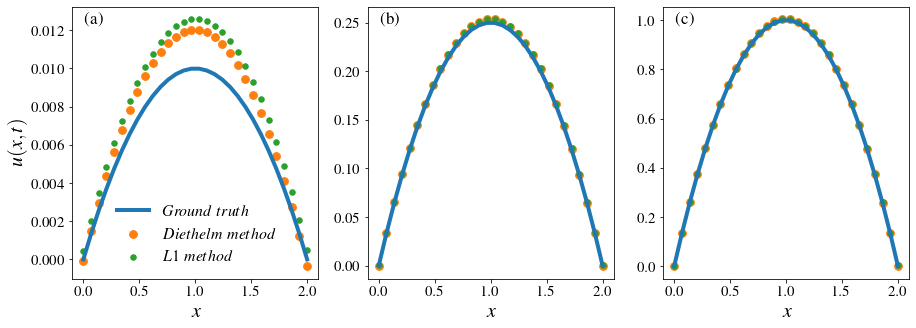

In [23]:
# ---- Configuration for this figure ------------------------------------
N_METHOD_COMP = 10                    # grid size used for both models
TMAX_METHOD_COMP = 1.0                # time window used for both models
TIME_SNAPSHOTS_METHOD = [0.1, 0.5, 1.0]

lb_m = [XMIN, 0.0]
ub_m = [XMAX, TMAX_METHOD_COMP]

# ---- Load both pre-trained models -------------------------------------
model_caputo = load_pretrained_model(
    f'WEIGHTS_{N_METHOD_COMP}t{N_METHOD_COMP}x_tmax{TMAX_METHOD_COMP}_cpt/my_model.tf',
    lb_m, ub_m,
)
model_l1 = load_pretrained_model(
    f'WEIGHTS_{N_METHOD_COMP}t{N_METHOD_COMP}x_tmax{TMAX_METHOD_COMP}_L1/my_model.tf',
    lb_m, ub_m,
)

# ---- Plot -------------------------------------------------------------
fig, ax = plt.subplots(1, 3, sharex=False, sharey=False, figsize=(15, 5))
axs = ax.flat
xspace = np.linspace(XMIN, XMAX, N_EVAL)
sub_cap = ['(a)', '(b)', '(c)']

for sub_p, t_snap in enumerate(TIME_SNAPSHOTS_METHOD):
    tspace = np.full(N_EVAL, t_snap)
    X_eval = np.stack([xspace, tspace], axis=1)

    pred_caputo = model_caputo(X_eval)
    pred_l1 = model_l1(X_eval)
    y_ref = exact_solution(xspace, tspace)

    axs[sub_p].plot(xspace, y_ref, label=r'$Ground\ truth$',
                    lw=LINE_WIDTH[0], color=COLORS[0])
    axs[sub_p].scatter(xspace, pred_caputo, label=r'$Diethelm\ method$',
                       marker=MARKERS[0], s=60, color=COLORS[1])
    axs[sub_p].scatter(xspace, pred_l1, label=r'$L1\ method$',
                       marker=MARKERS[0], s=30, color=COLORS[2])

    axs[sub_p].set_xlabel('$x$')
    axs[sub_p].set_xlim((-0.1, 2.1))

    if sub_p == 0:
        axs[sub_p].set_ylabel('$u(x, t)$')
        axs[sub_p].legend(frameon=False)

    # Subplot label
    axs[sub_p].text(0.05, 0.98, sub_cap[sub_p],
                    transform=axs[sub_p].transAxes,
                    verticalalignment='top', weight='bold')
    axs[sub_p].locator_params(axis='x', nbins=5)

plt.savefig(f'Solutions_NN_and_exact_{N_METHOD_COMP}points_tmax{TMAX_METHOD_COMP}.png',
            dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## 8. Contour Comparison — PINN vs Reference

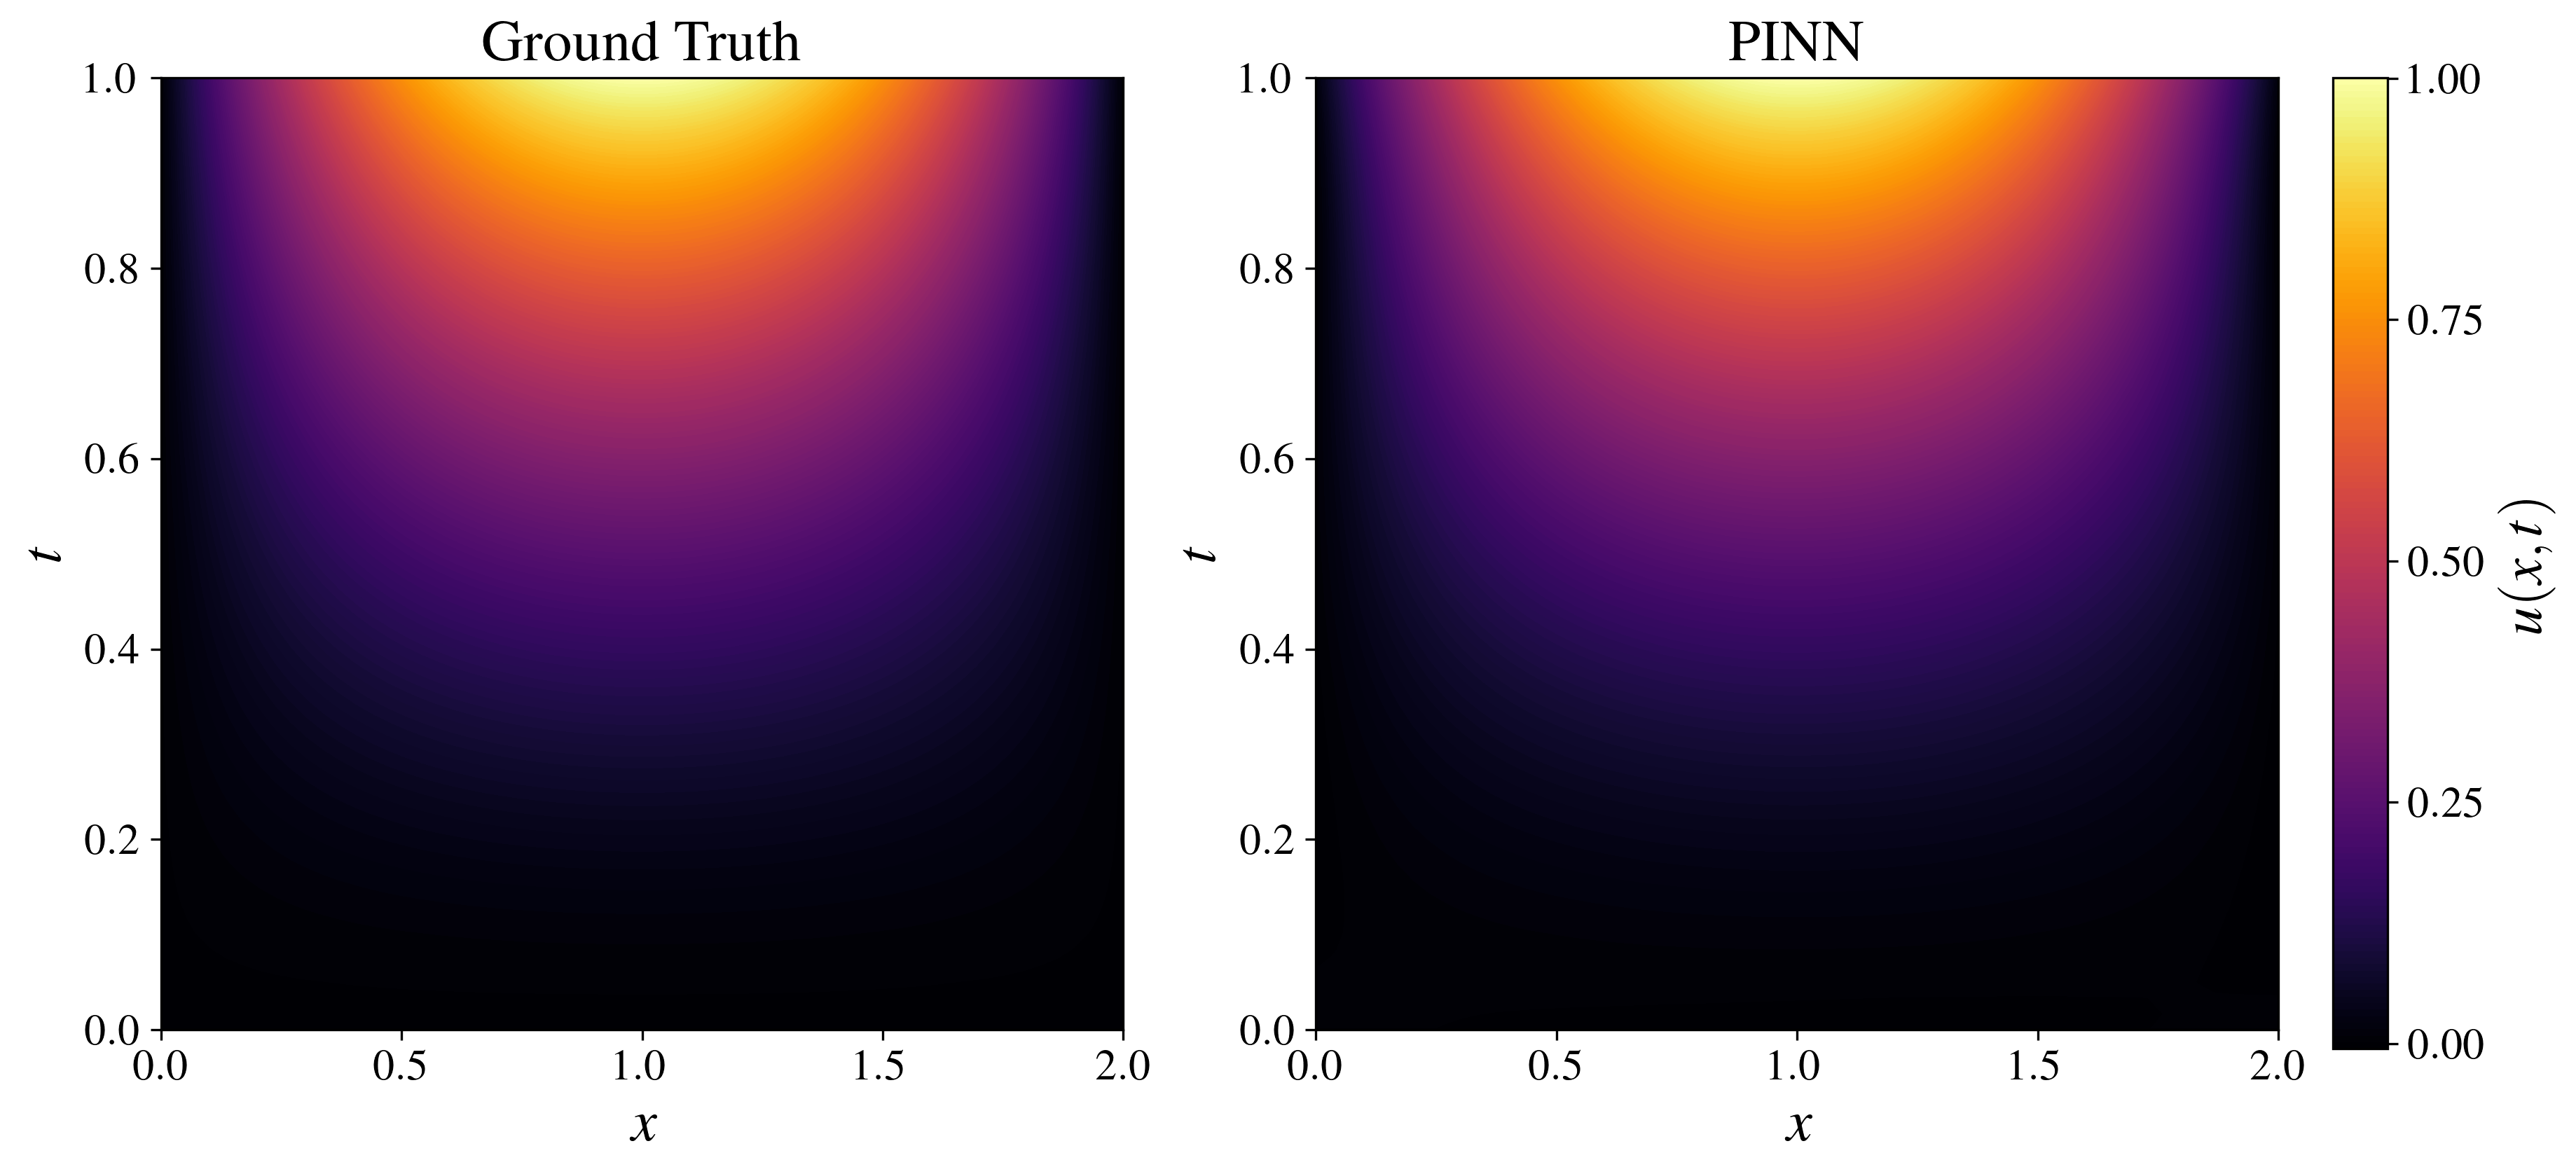

In [22]:
# Choose which trained model to visualize
TMAX_CONTOUR = 1.0
NX_CONTOUR, NT_CONTOUR = 50, 50
NUM_PLOT_POINTS = 60

lb_c = [XMIN, 0.0]
ub_c = [XMAX, TMAX_CONTOUR]

model = load_pretrained_model(
    f'WEIGHTS_{NT_CONTOUR}t{NX_CONTOUR}x_tmax{TMAX_CONTOUR}_cpt/my_model.tf',
    lb_c, ub_c
)

# Evaluation grid
x_eval = np.linspace(XMIN, XMAX, NUM_PLOT_POINTS)
t_eval = np.linspace(0.0, TMAX_CONTOUR, NUM_PLOT_POINTS)
X_grid, T_grid = np.meshgrid(x_eval, t_eval)
X_flat = np.stack([X_grid.flatten(), T_grid.flatten()], axis=1)

u_pred = model(X_flat).numpy().reshape((NUM_PLOT_POINTS, NUM_PLOT_POINTS))
u_ref = exact_solution(X_grid.flatten(), T_grid.flatten()).reshape(
    (NUM_PLOT_POINTS, NUM_PLOT_POINTS)
)

# Side-by-side contour plots with a shared colorbar
fig = plt.figure(figsize=(13, 6), dpi=300)
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.2)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

combined_min = min(u_pred.min(), u_ref.min())
combined_max = max(u_pred.max(), u_ref.max())
levels = np.linspace(combined_min, combined_max, 150)

cp_ref = ax1.contourf(X_grid, T_grid, u_ref, cmap='inferno', levels=levels)
ax1.set_title('Ground Truth')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$t$')

cp_nn = ax2.contourf(X_grid, T_grid, u_pred, cmap='inferno', levels=levels)
ax2.set_title('PINN')
ax2.set_xlabel('$x$')
ax2.set_ylabel('$t$')

cbar_ax = fig.add_axes([0.92, 0.11, 0.02, 0.77])
cbar = fig.colorbar(cp_ref, cax=cbar_ax)
cbar.set_label('$u(x, t)$')
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()

filename = f'contour_of_NN_{NT_CONTOUR}points_tmax{TMAX_CONTOUR}s.png'
plt.savefig(filename, dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## 9. Quantitative Evaluation

Computes the quantitative error metrics requested by Reviewer 1 (Q2) directly
from the saved model weights — **no re-training required**. Runtimes are
taken from Table 2 of the manuscript (already reported for the Diethelm
method).

The section produces:

- **L2 relative error** and **L∞ absolute error** for each saved Diethelm
  configuration (N = 10, 20, 50).
- **Error vs number of collocation points** (log-log).
- **Error vs runtime** (log-log) using the runtimes from Table 2.

### 9.1 Error metrics for saved models

In [31]:
def compute_error_metrics(model, tmax, num_points=60):
    """L2 relative error and L-infinity absolute error against the exact solution.

    The evaluation grid is `num_points` x `num_points` on [XMIN, XMAX] x [0, tmax].
    """
    x_eval = np.linspace(XMIN, XMAX, num_points)
    t_eval = np.linspace(0.0, tmax, num_points)
    X_grid, T_grid = np.meshgrid(x_eval, t_eval)
    X_flat = np.stack([X_grid.flatten(), T_grid.flatten()], axis=1)

    u_pred = model(X_flat).numpy().flatten()
    u_ref = exact_solution(X_grid.flatten(), T_grid.flatten())

    l2_rel = np.linalg.norm(u_pred - u_ref) / np.linalg.norm(u_ref)
    linf_abs = np.max(np.abs(u_pred - u_ref))
    return float(l2_rel), float(linf_abs)

### 9.2 Evaluate all Diethelm configurations

Runtimes (minutes) and iteration counts are copied from Table 2 of the
manuscript. If you re-run any case, update the numbers here to keep the
table and the plot consistent.

In [32]:
# ---- Table 2 data (Diethelm method) -----------------------------------
# Each entry: (N, tmax, runtime_minutes, iterations, weights_path)
DIETHELM_CASES = [
    (10, 1.0, 10, 93000,
     'WEIGHTS_10t10x_tmax1.0_cpt/my_model.tf'),
    (20, 1.0, 30, 57400,
     'WEIGHTS_20t20x_tmax1.0_cpt/my_model.tf'),
    (50, 1.0, 30, 4400,
     'WEIGHTS_50t50x_tmax1.0_cpt/my_model.tf'),
]

# ---- Compute error metrics for each case ------------------------------
lb_eval = [XMIN, 0.0]
results = []
for N, tmax, runtime_min, iterations, weights_path in DIETHELM_CASES:
    ub_eval = [XMAX, tmax]
    model = load_pretrained_model(weights_path, lb_eval, ub_eval)
    l2, linf = compute_error_metrics(model, tmax=tmax)
    results.append({
        'N': N,
        'tmax': tmax,
        'runtime_minutes': runtime_min,
        'iterations': iterations,
        'l2_rel': l2,
        'linf_abs': linf,
    })
    print(f'N={N:3d}, tmax={tmax}: L2 rel = {l2:.4e}, '
          f'Linf abs = {linf:.4e}, runtime = {runtime_min} min')

N= 10, tmax=1.0: L2 rel = 7.6674e-03, Linf abs = 5.0411e-03, runtime = 10 min
N= 20, tmax=1.0: L2 rel = 1.0156e-02, Linf abs = 5.7489e-03, runtime = 30 min
N= 50, tmax=1.0: L2 rel = 5.1022e-03, Linf abs = 1.3343e-02, runtime = 30 min


### 9.3 Summary table (for the paper)

In [33]:
import pandas as pd

df = pd.DataFrame(results)
df = df[['N', 'tmax', 'iterations', 'runtime_minutes', 'l2_rel', 'linf_abs']]
df.columns = ['N', 'tmax', 'Iterations', 'Runtime (min)',
              'L2 rel error', 'L-inf abs error']

# Save for the paper and print a clean version
df.to_csv('quantitative_metrics_diethelm.csv', index=False)
print(df.to_string(index=False,
                   formatters={'L2 rel error': '{:.3e}'.format,
                               'L-inf abs error': '{:.3e}'.format}))

 N  tmax  Iterations  Runtime (min) L2 rel error L-inf abs error
10   1.0       93000             10    7.667e-03       5.041e-03
20   1.0       57400             30    1.016e-02       5.749e-03
50   1.0        4400             30    5.102e-03       1.334e-02


### 9.4 Error-vs-N and error-vs-runtime curves

Standard log-log plots suitable for the revised manuscript.

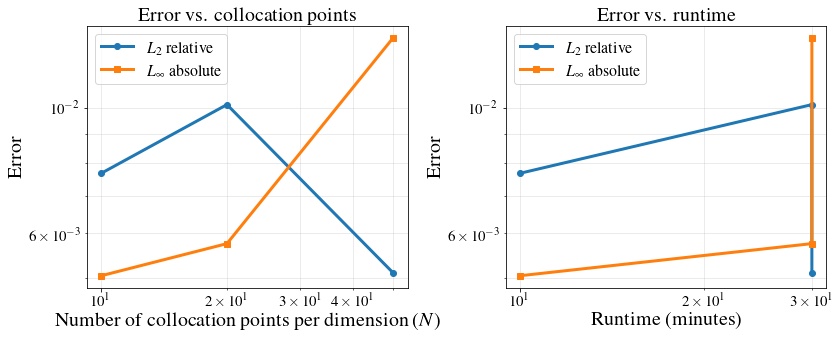

In [34]:
Ns = [r['N'] for r in results]
l2_errs = [r['l2_rel'] for r in results]
linf_errs = [r['linf_abs'] for r in results]
runtimes = [r['runtime_minutes'] for r in results]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# ---- Error vs N -------------------------------------------------------
axs[0].loglog(Ns, l2_errs, 'o-', label=r'$L_2$ relative', lw=LINE_WIDTH[1])
axs[0].loglog(Ns, linf_errs, 's-', label=r'$L_\infty$ absolute', lw=LINE_WIDTH[1])
axs[0].set_xlabel('Number of collocation points per dimension ($N$)')
axs[0].set_ylabel('Error')
axs[0].set_title('Error vs. collocation points')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend()

# ---- Error vs runtime -------------------------------------------------
axs[1].loglog(runtimes, l2_errs, 'o-', label=r'$L_2$ relative', lw=LINE_WIDTH[1])
axs[1].loglog(runtimes, linf_errs, 's-', label=r'$L_\infty$ absolute', lw=LINE_WIDTH[1])
axs[1].set_xlabel('Runtime (minutes)')
axs[1].set_ylabel('Error')
axs[1].set_title('Error vs. runtime')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.savefig('error_scans_diethelm.png', dpi=300, bbox_inches='tight')
plt.show()